In [105]:
import numpy as np
import matplotlib.pyplot as plt

In [106]:
def pds_awgn(N, fs, potencia_W):
    tt = np.arange(start = 0, step = 1/fs, stop = N*(1/fs))
    desvio_std = np.sqrt(potencia_W)
    media = 0
    xx = np.random.normal(loc=media, scale=desvio_std, size=N)
    return xx, tt

def pds_sen_ruidosa(nn = 1000, fs = 1000, freq = 1, Amax = np.sqrt(2), dc = 0, phase = 0, SNR_db = "inf"):
    tt = np.arange(start = 0, step = 1/fs, stop = nn*(1/fs))
    x1 = dc + Amax * np.sin(2*np.pi * freq * tt + phase)

    if SNR_db != "inf" and (type(SNR_db) == float or type(SNR_db) == int):
        pot_senal = 10*np.log10((Amax**2) / 2)
        pot_ruido = pot_senal - SNR_db
        x2, tt = pds_awgn(nn, fs, potencia_W = 10**(pot_ruido/10))
        xx = x1 + x2
    else:
        xx = x1

    return xx, tt

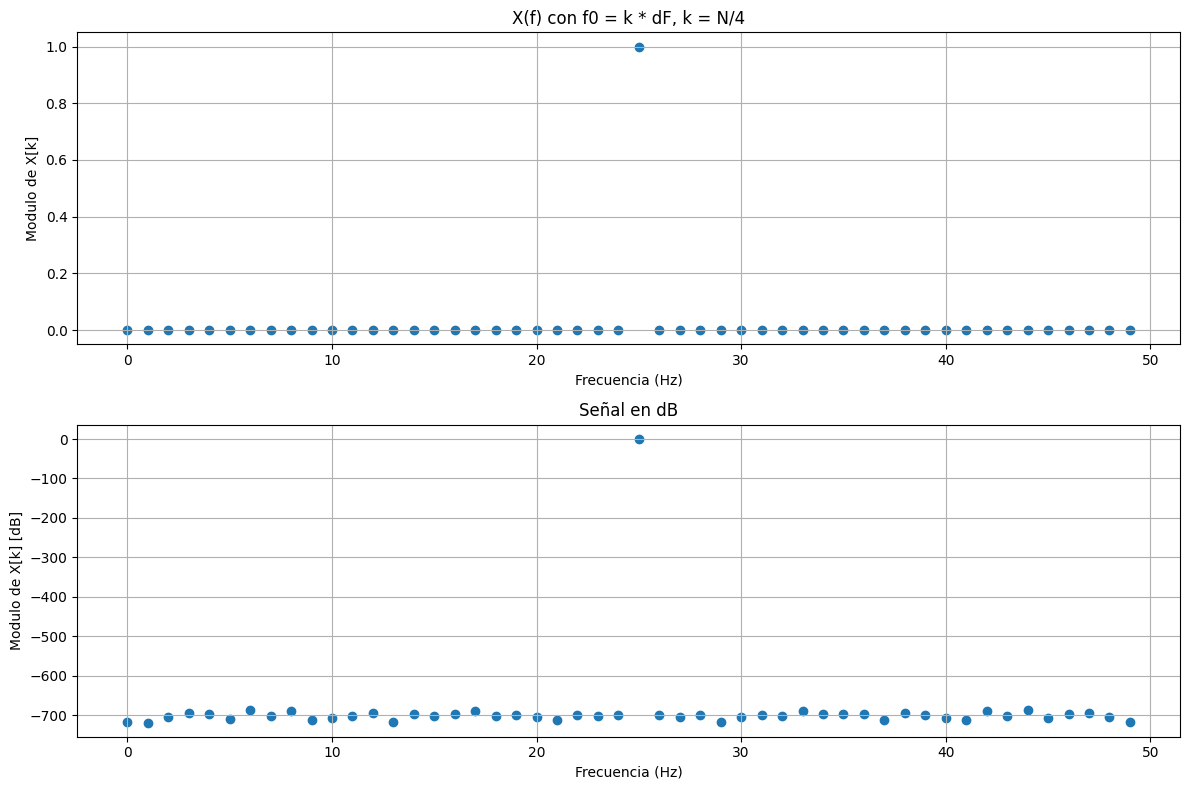

X[20]_dB = -704.9083722150854
X[21]_dB = -712.5757668262302
X[22]_dB = -699.1661055705003
X[23]_dB = -701.8255700177006
X[24]_dB = -697.9679646585271
X[25]_dB = 2.2204460492503127e-15
X[26]_dB = -697.9679646585271
X[27]_dB = -703.6071236875289
X[28]_dB = -699.1661055705003
X[29]_dB = -716.7602034107387


In [107]:


def plot_señal(xx, fs, N, title=""):
    xx_fft = np.fft.fft(xx)
    xx_fft = xx_fft[:len(xx_fft)//2]

    figure, axs = plt.subplots(2, 1, figsize=(12, 8))
    axs[0].scatter(np.arange(len(xx_fft)) * fs / N, 2*(np.abs(xx_fft)/N)**2, label='f0 = fs / 4')
    axs[0].set_xlabel('Frecuencia (Hz)')
    axs[0].set_ylabel('Modulo de X[k]')
    axs[0].grid(True)
    axs[0].set_title(title)


    axs[1].scatter(np.arange(len(xx_fft)) * fs / N, 10*np.log(2*(np.abs(xx_fft)/N)**2), label='f0 = fs / 4')
    axs[1].set_xlabel('Frecuencia (Hz)')
    axs[1].set_ylabel('Modulo de X[k] [dB]')
    axs[1].grid(True)
    axs[1].set_title("Señal en dB")

    plt.tight_layout()
    plt.show()

    return xx_fft

fs = 100
N = 100
res_espectral = fs / N

k0 = N / 4
f0 = k0 * res_espectral

xx, tt = pds_sen_ruidosa(N, fs, freq=f0)
xx_fft = plot_señal(xx, fs, N, title=f"X(f) con f0 = k * dF, k = N/4")
xx_fft_db = 10*np.log(2*(np.abs(xx_fft)/N)**2)

for i in range(len(xx_fft)//2 - 5, len(xx_fft)//2 + 5):
    print(f"X[{i}]_dB = {xx_fft_db[i]}")

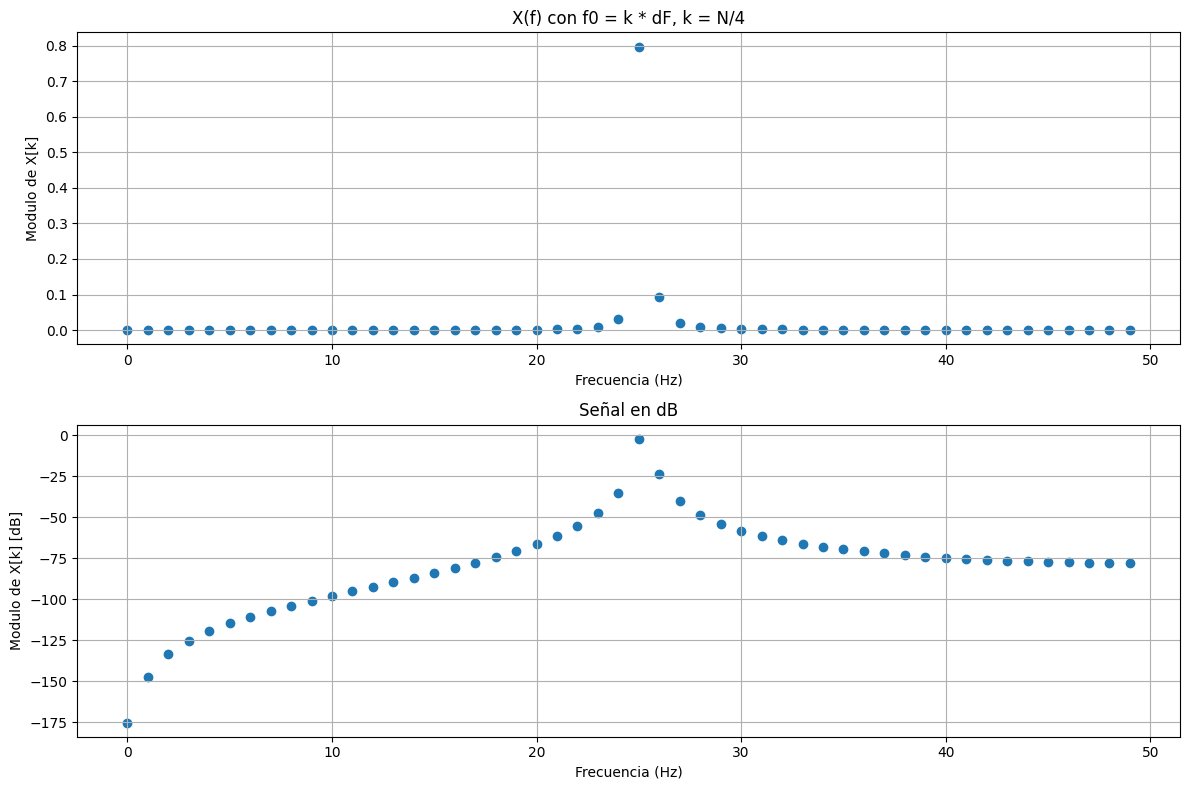

X[20]_dB = -73.46196049588906
X[21]_dB = -68.51459540631964
X[22]_dB = -62.45408764301324
X[23]_dB = -54.4264877939036
X[24]_dB = -42.01641893834851
X[25]_dB = -9.189131789059925
X[26]_dB = -30.5360192960906
X[27]_dB = -46.86742426319672
X[28]_dB = -55.30124240921532
X[29]_dB = -60.90517559242777


In [108]:
fs = 100
N = 100
res_espectral = fs / N

k0 = N / 4 + .25
f0 = k0 * res_espectral

xx, tt = pds_sen_ruidosa(N, fs, freq=f0)
xx_fft = plot_señal(xx, fs, N, title=f"X(f) con f0 = k * dF, k = N/4")
xx_fft_db = 10*np.log((np.abs(xx_fft)/N)**2)

for i in range(len(xx_fft)//2 - 5, len(xx_fft)//2 + 5):
    print(f"X[{i}]_dB = {xx_fft_db[i]}")

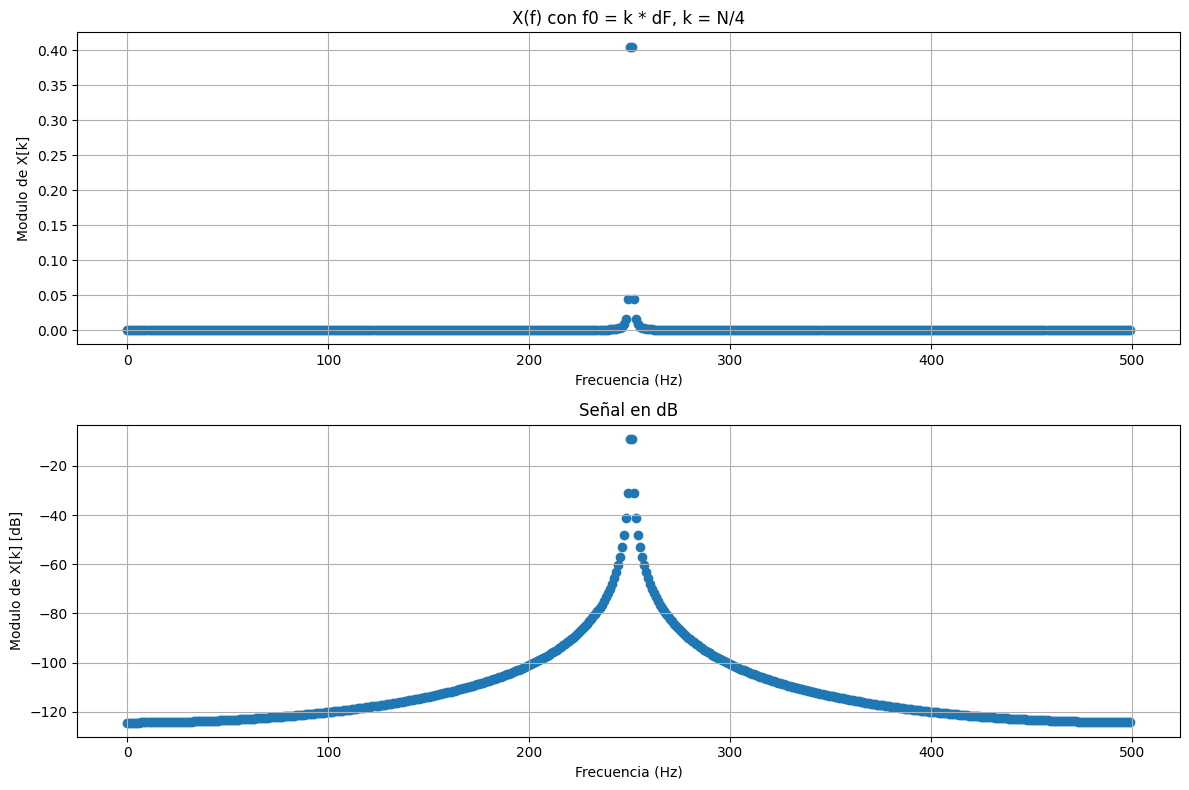

X[245]_dB = -63.91813620707954
X[246]_dB = -59.90584090068151
X[247]_dB = -54.880407721613345
X[248]_dB = -48.15155517217481
X[249]_dB = -37.935371684848064
X[250]_dB = -15.963191708902574
X[251]_dB = -15.962994316003146
X[252]_dB = -37.93477950225251
X[253]_dB = -48.15056818819351
X[254]_dB = -54.879025916763105


In [109]:
fs = 1000
N = 1000
res_espectral = fs / N

k0 = N / 4 + .5
f0 = k0 * res_espectral
f0 = fs/4 + res_espectral/2

xx, tt = pds_sen_ruidosa(N, fs, freq=f0)
xx_fft = plot_señal(xx, fs, N, title=f"X(f) con f0 = k * dF, k = N/4")
xx_fft_db = 10*np.log((np.abs(xx_fft)/N)**2)

for i in range(len(xx_fft)//2 - 5, len(xx_fft)//2 + 5):
    print(f"X[{i}]_dB = {xx_fft_db[i]}")